In [55]:
import pandas as pd 
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
with open('history/watch-history.json', 'r', encoding = 'utf-8') as f:
    watch_data = json.load(f)

In [57]:
with open('history/search-history.json', 'r', encoding = 'utf-8') as f:
    search_data = json.load(f)

In [58]:
df_watch = pd.DataFrame(watch_data)
df_search = pd.DataFrame(search_data)

In [59]:
print("---Watch History Columns---")
print(df_watch.columns)

---Watch History Columns---
Index(['header', 'title', 'titleUrl', 'time', 'products', 'details',
       'activityControls', 'subtitles', 'description'],
      dtype='object')


In [60]:
print("---Search History Columns---")
print(df_search.columns)

---Search History Columns---
Index(['header', 'title', 'titleUrl', 'description', 'time', 'products',
       'details', 'activityControls'],
      dtype='object')


In [61]:
print("Watch History Record Structure:")
print(df_watch.iloc[0].to_dict())

Watch History Record Structure:
{'header': 'YouTube', 'title': 'Watched Groww_UAC_Vibhash_IN_L', 'titleUrl': 'https://www.youtube.com/watch?v=vMl6M-tP_7k', 'time': '2026-07-11T04:03:31.538Z', 'products': ['YouTube'], 'details': [{'name': 'From Google Ads'}], 'activityControls': ['Web & App Activity', 'YouTube watch history'], 'subtitles': nan, 'description': nan}


In [62]:
print("Search History Record Structure:")
print(df_search.iloc[0].to_dict())

Search History Record Structure:
{'header': 'YouTube', 'title': 'Watched Google Cloud: Your one-stop shop for AI and everything cloud', 'titleUrl': 'https://www.youtube.com/watch?v=BoiX4OB9s1A', 'description': 'Watched at 08:32', 'time': '2026-07-11T03:02:46.555Z', 'products': ['YouTube'], 'details': [{'name': 'From Google Ads'}], 'activityControls': ['Web & App Activity', 'YouTube watch history', 'YouTube search history']}


In [63]:
df_watch_clean = df_watch.copy()

df_watch_clean['timestamp'] = pd.to_datetime(df_watch_clean['time'], format = 'ISO8601')

df_watch_clean['date'] = df_watch_clean['timestamp'].dt.date
df_watch_clean['hour'] = df_watch_clean['timestamp'].dt.hour
df_watch_clean['day_of_week'] = df_watch_clean['timestamp'].dt.day_name()

df_watch_clean['channel'] = df_watch_clean['subtitles'].apply(
    lambda x: x[0]['name'] if isinstance(x, list) and len(x) > 0 else 'Unknown'
)

df_watch_clean['video_title'] = df_watch_clean['title'].str.replace('watched ', '', regex = False)

print("Cleaned Data Sample:")
print(df_watch_clean[['date', 'hour', 'day_of_week', 'channel', 'video_title']].head())

Cleaned Data Sample:
         date  hour day_of_week      channel  \
0  2026-07-11     4    Saturday      Unknown   
1  2026-07-11     3    Saturday  VTU Academy   
2  2026-07-11     3    Saturday      Unknown   
3  2026-07-11     3    Saturday   EDU  YODHA   
4  2026-07-11     3    Saturday   EDU  YODHA   

                                         video_title  
0                     Watched Groww_UAC_Vibhash_IN_L  
1  Watched Module 1 Research Methodology RM & IPR...  
2  Watched OAI ICC ImageGen2 0 INTERIOR INDO 10s ...  
3  Watched Research Methodology and IPR | BRMK557...  
4  Watched Research Methodology and IPR|BRMK557| ...  


In [64]:
top_channels = df_watch_clean['channel'].value_counts().head(10)

print("=== MY TOP 10 CHANNELS ===")
print(top_channels)

=== MY TOP 10 CHANNELS ===
channel
Unknown                 937
Rj Mobile 01             40
Rajeev Kanth | BEPEC     33
Crazy Yogi               28
IAS Illumine             27
RIO Classes              24
Sundas Khalid            24
GothamChess              24
Simplilearn              23
Ishan Sharma             23
Name: count, dtype: int64


In [65]:
print("--- SAMPLE OF UNKNOWN CHANNELS ---")
print(df_watch_clean[df_watch_clean['channel'] == 'Unknown']['video_title'].head(15))

--- SAMPLE OF UNKNOWN CHANNELS ---
0                         Watched Groww_UAC_Vibhash_IN_L
2      Watched OAI ICC ImageGen2 0 INTERIOR INDO 10s ...
5      Watched Google Cloud: Your one-stop shop for A...
7      Watched Shortened: Groww_UAC_Trading_ToughGree...
8                         Watched YT_Masthead_Static_15s
32                            Used Shorts creation tools
38     Viewed https://www.youtube.com/post/UgkxNH3WA4...
52                          Watched AI CH P3 431 UV 9×16
55     Watched Virasat Bhi Vikas Bhi: 12 Years of Tra...
58               Watched 24/7 AI English Mentor உங்க கூட
61                    Watched Hit The Button, Win $1,000
100    Watched https://www.youtube.com/watch?v=FBLu6g...
109    Watched https://www.youtube.com/watch?v=8m86_J...
127    Watched https://www.youtube.com/watch?v=xM2eZv...
134    Watched https://www.youtube.com/watch?v=-ZjBP4...
Name: video_title, dtype: object


In [66]:
def flag_activity_type(title):
    title_str = str(title).lower()
   
    if 'uac_' in title_str or 'masthead' in title_str or '15s' in title_str or '10s' in title_str:
        return 'Advertisement'
    
    elif 'used shorts creation tools' in title_str:
        return 'App Interaction'
    
    elif 'viewed http' in title_str:
        return 'Community Post'
    
    else:
        return 'Video'


In [67]:
df_watch_clean['activity_type'] = df_watch_clean['title'].apply(flag_activity_type)

In [68]:
df_videos_only = df_watch_clean[df_watch_clean['activity_type'] == 'Video'].copy()

In [69]:
print("Activity Breakdown:")
print(df_watch_clean['activity_type'].value_counts())

Activity Breakdown:
activity_type
Video              4495
Advertisement        17
App Interaction       1
Community Post        1
Name: count, dtype: int64


In [70]:
print("\n--- NEW TOP 10 REAL CHANNELS ---")
print(df_videos_only['channel'].value_counts().head(10))


--- NEW TOP 10 REAL CHANNELS ---
channel
Unknown                 918
Rj Mobile 01             40
Rajeev Kanth | BEPEC     33
Crazy Yogi               28
IAS Illumine             27
GothamChess              24
RIO Classes              24
Sundas Khalid            24
Ishan Sharma             23
Simplilearn              23
Name: count, dtype: int64


In [71]:
unknown_videos = df_videos_only[df_videos_only['channel'] == 'Unknown']
print("--- REMAINING UNKNOWN VIDEOS SAMPLE ---")
print(unknown_videos[['title', 'titleUrl']].head(20))

--- REMAINING UNKNOWN VIDEOS SAMPLE ---
                                                 title  \
5    Watched Google Cloud: Your one-stop shop for A...   
52                        Watched AI CH P3 431 UV 9×16   
55   Watched Virasat Bhi Vikas Bhi: 12 Years of Tra...   
58             Watched 24/7 AI English Mentor உங்க கூட   
61                  Watched Hit The Button, Win $1,000   
100  Watched https://www.youtube.com/watch?v=FBLu6g...   
109  Watched https://www.youtube.com/watch?v=8m86_J...   
127  Watched https://www.youtube.com/watch?v=xM2eZv...   
134  Watched https://www.youtube.com/watch?v=-ZjBP4...   
165  Watched https://www.youtube.com/watch?v=W_XsGM...   
166  Watched https://www.youtube.com/watch?v=lZqaWP...   
167  Watched https://www.youtube.com/watch?v=BgWGSU...   
178  Watched https://www.youtube.com/watch?v=att4hM...   
193  Watched https://www.youtube.com/watch?v=VNOtgm...   
201  Watched https://www.youtube.com/watch?v=zn-nto...   
206  Watched https://www.youtube

In [72]:
def clean_unknown_channels(row):
    if row['channel'] == 'Unknown':
        
        if 'youtube.com/watch' in str(row['title']):
            return 'Deleted/Private Content'
            
        else:
            return 'Youtube Shorts / Unlisted'
        
        return row['channel']

df_videos_only['cleaned_channel'] = df_videos_only.apply(clean_unknown_channels, axis = 1)

channel_map = {
    'Rajeev Kanth | BEPEC': 'Data Science/Education',
    'Sundas Khalid': 'Data Science/Education',
    'Simplilearn': 'Data Science/Education',
    'IAS Illumine': 'Exam Prep/Education',
    'RIO Classes': 'Exam Prep/Education',
    'Ishan Sharma': 'Tech/Career',
    'GothamChess': 'Entertainment/Gaming',
    'Crazy Yogi': 'Entertainment',
    'Rj Mobile 01': 'Entertainment/Tech Review',
    'Deleted/Private Content': 'Hidden/Deleted Media',
    'YouTube Shorts / Unlisted': 'Shorts/Passive Consumption'
}

df_videos_only['focus_category'] = df_videos_only['cleaned_channel'].map(channel_map).fillna('Other Entertainment')

print("--- MY TIME VISUALIZATION BREAKDOWN ---")
print(df_videos_only['focus_category'].value_counts())

--- MY TIME VISUALIZATION BREAKDOWN ---
focus_category
Other Entertainment     4064
Hidden/Deleted Media     431
Name: count, dtype: int64


In [73]:
def smart_categorizer(row):
    title = str(row['video_title']).lower()
    channel = str(row['cleaned_channel']).lower()
    
    # 1. Handle the deleted media first
    if row['cleaned_channel'] == 'Hidden/Deleted Media':
        return 'Hidden/Deleted Media'
    
    # 2. Check for Data Science & Tech Keywords
    if any(kw in title for kw in ['python', 'data', 'analytics', 'sql', 'excel', 'power bi', 'tableau', 'coding', 'machine learning', 'ai']):
        return 'Data Science & Tech'
    
    # 3. Check for Education & Exam Prep Keywords
    if any(kw in title for kw in ['class', 'ias', 'upsc', 'exam', 'tutorial', 'learn', 'course', 'preparation']):
        return 'Education & Exam Prep'
    
    # 4. Check for known entertainment channels from your top list
    if any(ch in channel for ch in ['gothamchess', 'crazy yogi', 'rj mobile']):
        return 'Entertainment (Top Channels)'
        
    # 5. Default fallback for the rest
    return 'General Entertainment / Other'

# Apply our smart keyword logic
df_videos_only['focus_category'] = df_videos_only.apply(smart_categorizer, axis=1)

# Print the brand new breakdown
print("--- NEW SMART TIME VISUALIZATION BREAKDOWN ---")
print(df_videos_only['focus_category'].value_counts())

--- NEW SMART TIME VISUALIZATION BREAKDOWN ---
focus_category
General Entertainment / Other    3155
Data Science & Tech              1010
Education & Exam Prep             330
Name: count, dtype: int64


In [74]:
# Create a cross-tabulation of Hour vs Focus Category
hourly_habits = pd.crosstab(df_videos_only['hour'], df_videos_only['focus_category'])

print("--- HOURLY BEHAVIOR MATRIX SAMPLE ---")
print(hourly_habits.head(10))

--- HOURLY BEHAVIOR MATRIX SAMPLE ---
focus_category  Data Science & Tech  Education & Exam Prep  \
hour                                                         
0                                 5                      1   
1                                41                     10   
2                                82                     26   
3                                64                     18   
4                                26                     14   
5                                56                     16   
6                                70                     23   
7                                48                     16   
8                                69                     23   
9                                58                     14   

focus_category  General Entertainment / Other  
hour                                           
0                                          22  
1                                         123  
2                        

<Figure size 1400x700 with 0 Axes>

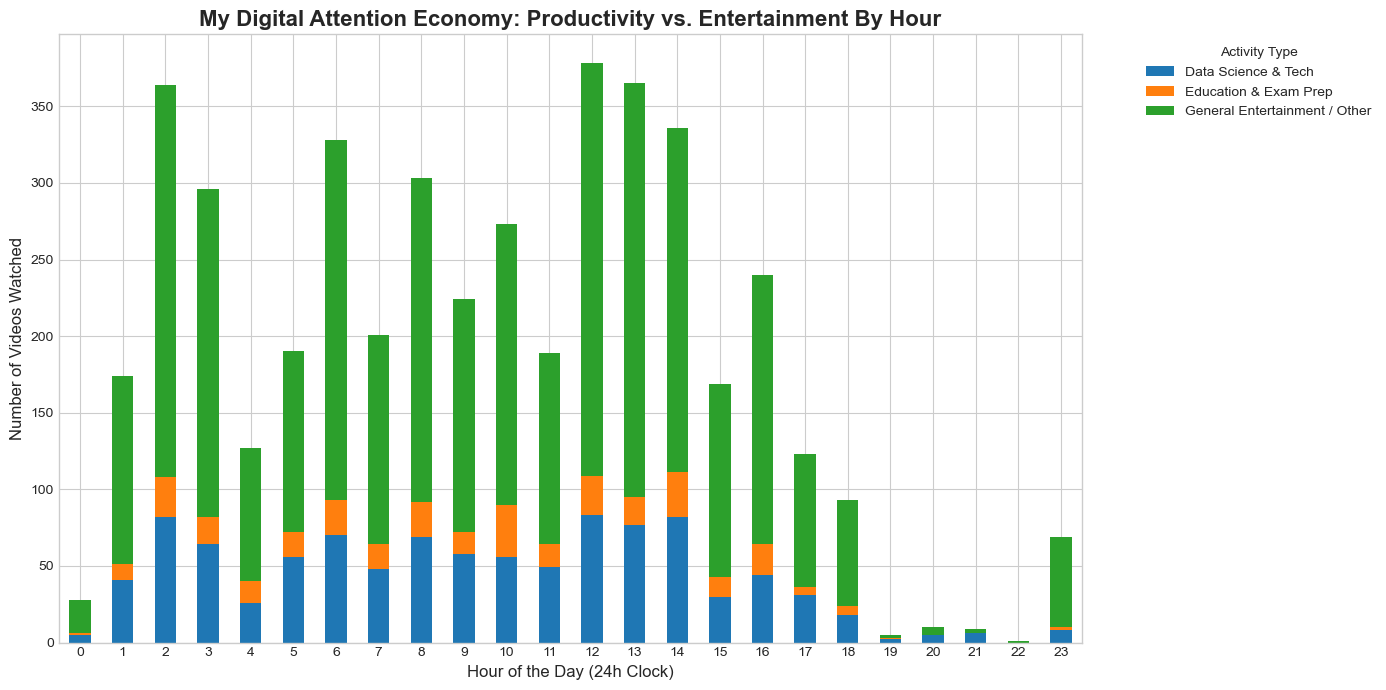

In [75]:
# Set style for a clean, resume-worthy project look
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 7))

# Calculate the full crosstab across all hours
hourly_habits_full = pd.crosstab(df_videos_only['hour'], df_videos_only['focus_category'])

# Plot a stacked bar chart
hourly_habits_full.plot(kind='bar', stacked=True, figsize=(14, 7), 
                        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

plt.title('My Digital Attention Economy: Productivity vs. Entertainment By Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (24h Clock)', fontsize=12)
plt.ylabel('Number of Videos Watched', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the plot automatically to your project directory
plt.savefig('hourly_productivity_trends.png', dpi=300)
plt.show()

In [76]:
# 1. Clean up Search History
df_search_clean = df_search.copy()
df_search_clean['timestamp'] = pd.to_datetime(df_search_clean['time'], format='ISO8601')
df_search_clean['date'] = df_search_clean['timestamp'].dt.date

# Clean the search queries (removing the prefix 'Searched for ')
df_search_clean['query'] = df_search_clean['title'].str.replace('Searched for ', '', regex=False)

# 2. Extract Top 15 Search Queries
print("--- YOUR TOP 15 SEARCH QUERIES ---")
print(df_search_clean['query'].value_counts().head(15))

--- YOUR TOP 15 SEARCH QUERIES ---
query
Watched Get Started on Google Cloud for Free                                                            9
Watched You Got This | adidas and Indian Cricket Team                                                   8
Watched First Job 16X9                                                                                  7
Watched An Exciting Career That Requires No Programming Skills                                          6
Watched MIT World Peace University| 40 Years of Academic Excellence                                     5
Watched Coca-Cola Halftime!                                                                             5
Watched GITAM Deemed to be University                                                                   5
cs50                                                                                                    4
blood relation reasoning tricks                                                                         4
Watch

In [77]:
# 1. Flag educational search queries
df_search_clean['is_edu_search'] = df_search_clean['query'].str.lower().str.contains(
    'python|data|analytics|sql|excel|class|ias|upsc|exam|tutorial|learn|course', regex=True
).astype(int)

# 2. Group searches and watches by date
daily_edu_searches = df_search_clean.groupby('date')['is_edu_search'].sum().reset_index(name='edu_searches')

df_videos_only['is_edu_watch'] = df_videos_only['focus_category'].isin(['Data Science & Tech', 'Education & Exam Prep']).astype(int)
daily_edu_watches = df_videos_only.groupby('date')['is_edu_watch'].sum().reset_index(name='edu_watches')

# 3. Merge the datasets on date
behavior_merged = pd.merge(daily_edu_searches, daily_edu_watches, on='date', how='inner')

# 4. Calculate the Pearson Correlation Coefficient
correlation = behavior_merged['edu_searches'].corr(behavior_merged['edu_watches'])

print("--- DIGITAL BEHAVIOR INSIGHTS ---")
print(f"Correlation between your Intent (Searches) and Action (Watches): {correlation:.2f}")
if correlation > 0.5:
    print("Strong Alignment: When you search for learning material, you successfully follow through with watching it!")
elif correlation > 0.2:
    print("Moderate Alignment: You mix your learning searches with a fair amount of passive entertainment browsing.")
else:
    print("Low Alignment: Your search intent heavily diverges from what the YouTube algorithm hooks you into watching.")

--- DIGITAL BEHAVIOR INSIGHTS ---
Correlation between your Intent (Searches) and Action (Watches): 0.41
Moderate Alignment: You mix your learning searches with a fair amount of passive entertainment browsing.


In [80]:
# Save the final cleaned data to CSV files for dashboarding
df_videos_only.to_csv('cleaned_youtube_watches.csv', index=False)
df_search_clean.to_csv('cleaned_youtube_searches.csv', index=False)

print("DATA CLEANING COMPLETE!")
print("Saved 'cleaned_youtube_watches.csv' and 'cleaned_youtube_searches.csv' to your directory.")
print("You also have your trend chart saved as 'hourly_productivity_trends.png'.")

DATA CLEANING COMPLETE!
Saved 'cleaned_youtube_watches.csv' and 'cleaned_youtube_searches.csv' to your directory.
You also have your trend chart saved as 'hourly_productivity_trends.png'.
